Exercise 1:

Create a new code cell below where you define variables containing your name, your age in years, and your major. Create another cell that uses these variables and prints a concatenated string stating your name, major, and your age in years, months, and days (assuming today is your birthday ;)). The output should look like that:

Name: Science Cat, Major: Computer Science, Age: 94 years, or 1128 months, or 34310 days. 


In [ ]:
name = "Dylan Weiner"
age = 26
major = "Software Development"

In [ ]:
print(f"Name: {name}, Major: {major}, Age: {age} years, or {age * 12} months, {age * 365 + int(age / 4)} days.")

Name:Dylan, Major: Software Development, Age: 26 years, or 312 months, 9496 days


Exercise 2:

Write a function that finds the overlap of two sets and prints them. Initialize two sets, e.g., with values {13, 25, 37, 45, 13} and {14, 25, 38, 8, 45} and call this function with them.

In [13]:
set1 = {13, 25, 37, 45, 13}
set2 = {14, 25, 38, 8, 45}

def find_overlap(s1, s2):
    for i in s1:
        if i in s2:
            print(i)

def main():
    find_overlap(set1, set2)

if __name__ == "__main__":
    main()

45
25


Create a new pandas series with the lists given below that contain NFL team names and the number of Super Bowl titles they won. Use the names as indices, the wins as the data.

    Once the list is created, sort the series alphabetically by index.
    Print an overview of the statistical properties of the series. What's the mean number of wins?
    Filter out all teams that have won less than four Super Bowl titles
    A football team has 45 players. Update the series so that instead of the number of titles, it reflects the number of Super Bowl rings given to the players.
    Assume that each ring costs sign. For the Steelers, for example, this would correspond to:

Pittsburgh Steelers

In [21]:
import pandas as pd
# import matplotlib.pyplot as plt

teams = {"Pittsburgh Steelers": 6,
"New England Patriots": 6,
"Dallas Cowboys": 5,
"San Francisco 49ers": 5,
"Green Bay Packers": 4,
"New York Giants": 4,
"Denver Broncos": 3,
"Oakland/Los Angeles Raiders": 3,
"Washington Redskins": 2,
"Miami Dolphins": 2,
"Baltimore/Indianapolis Colts": 2,
"Baltimore Ravens": 2}

teams = dict(sorted(teams.items()))
mask = [i for i in teams if teams[i] > 3]
print(teams)
mean = sum(teams.values()) / len(teams)

newStats = teams
for i in newStats:
    newStats[i] = teams[i] * 45
    print(f"{i}: {newStats[i]} Rings")

for i in newStats:
    cost = newStats[i] * 30000
    print(f"{i}: ${cost}")

print(f"Mean: {mean}\nTeams with more than 3 Super Bowl wins: {mask}\n")

{'Baltimore Ravens': 2, 'Baltimore/Indianapolis Colts': 2, 'Dallas Cowboys': 5, 'Denver Broncos': 3, 'Green Bay Packers': 4, 'Miami Dolphins': 2, 'New England Patriots': 6, 'New York Giants': 4, 'Oakland/Los Angeles Raiders': 3, 'Pittsburgh Steelers': 6, 'San Francisco 49ers': 5, 'Washington Redskins': 2}
Baltimore Ravens: 90 Rings
Baltimore/Indianapolis Colts: 90 Rings
Dallas Cowboys: 225 Rings
Denver Broncos: 135 Rings
Green Bay Packers: 180 Rings
Miami Dolphins: 90 Rings
New England Patriots: 270 Rings
New York Giants: 180 Rings
Oakland/Los Angeles Raiders: 135 Rings
Pittsburgh Steelers: 270 Rings
San Francisco 49ers: 225 Rings
Washington Redskins: 90 Rings
Baltimore Ravens: $2700000
Baltimore/Indianapolis Colts: $2700000
Dallas Cowboys: $6750000
Denver Broncos: $4050000
Green Bay Packers: $5400000
Miami Dolphins: $2700000
New England Patriots: $8100000
New York Giants: $5400000
Oakland/Los Angeles Raiders: $4050000
Pittsburgh Steelers: $8100000
San Francisco 49ers: $6750000
Washing

Grab a year's worth of hourly SLC PM2.5 data in CSV form from here (at the bottom)

Pick one of the monitoring stations from the dataset and perform your analysis from the readings from that station.

Plot the readings from that station over the course of a year

Plot the mean pm2.5 level for each month using a bar chart.

Next, group the data by time of day (by hour), and plot the mean pollution level for each hour.

Use Box and Whisker plots of the monthly and hourly data groupings to provide a more complete view of the data.

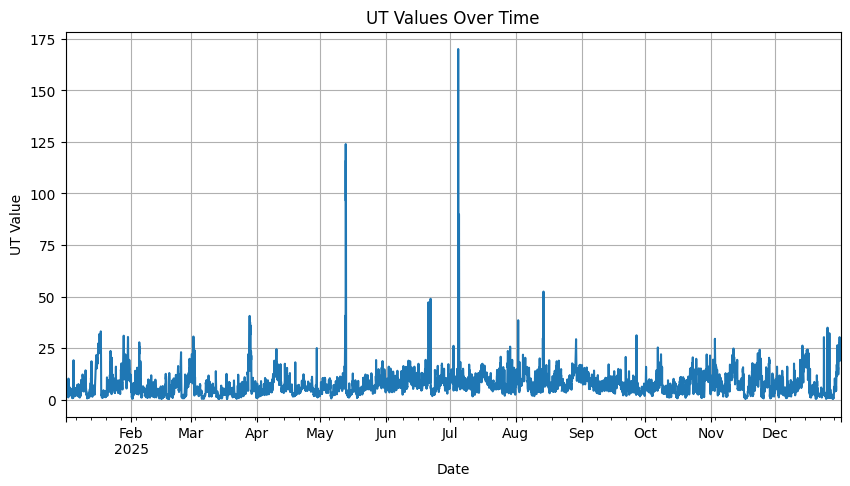

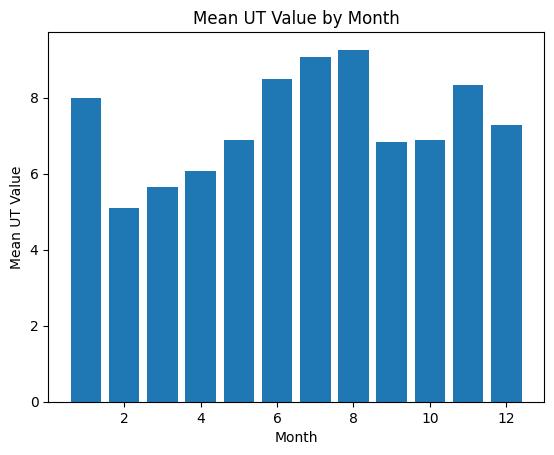

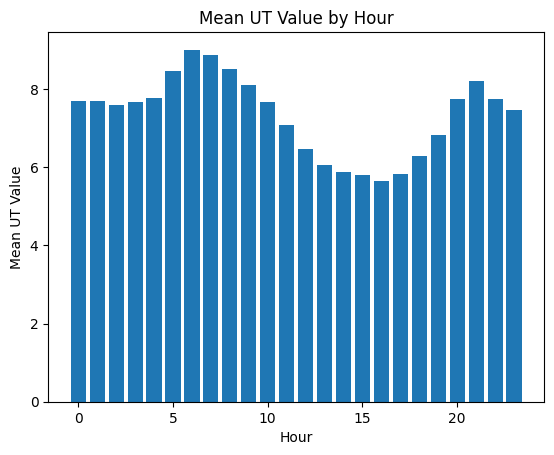

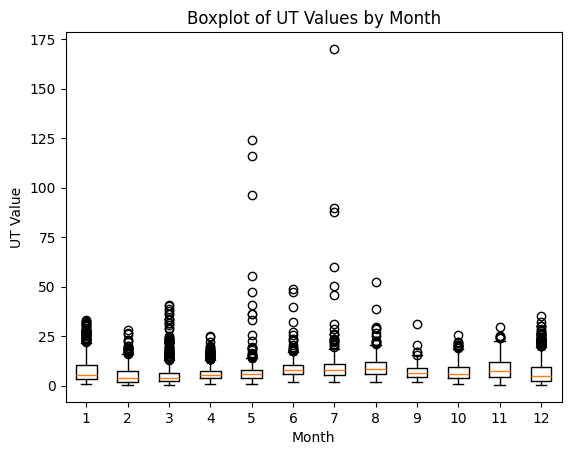

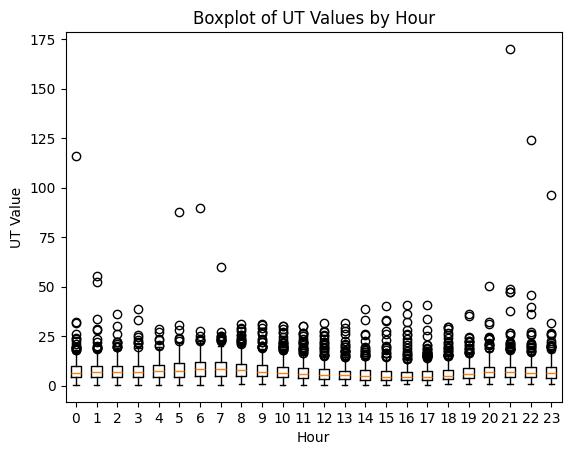

In [83]:
import matplotlib.pyplot as plt
import csv
import pandas as pd
import datetime

with open("2025-PM2.5.csv", "r") as data_set:
    df = pd.read_csv(data_set)

    blank_header = df.columns[0]
    df = df.rename(columns={blank_header: 'Date'})
    clean_dataframe = df.iloc[3:].copy()

    clean_dataframe['Date'] = pd.to_datetime(clean_dataframe['Date'], errors='coerce')
    clean_dataframe['UT'] = pd.to_numeric(clean_dataframe['UT'], errors='coerce')

    clean_dataframe.set_index('Date')['UT'].plot(figsize=(10, 5), grid=True)

    plt.title('UT Values Over Time')
    plt.ylabel('UT Value')
    plt.show()

    mean_monthly = clean_dataframe.groupby(clean_dataframe['Date'].dt.month)['UT'].mean()
    plt.bar(mean_monthly.index, mean_monthly.values)
    plt.title('Mean UT Value by Month')
    plt.xlabel('Month')
    plt.ylabel('Mean UT Value')
    plt.show()

    mean_hourly = clean_dataframe.groupby(clean_dataframe['Date'].dt.hour)['UT'].mean()
    plt.bar(mean_hourly.index, mean_hourly.values)
    plt.title('Mean UT Value by Hour')
    plt.xlabel('Hour')
    plt.ylabel('Mean UT Value')
    plt.show()

    plt.boxplot([clean_dataframe[clean_dataframe['Date'].dt.month == h]['UT'].dropna() for h in range(1, 13)], tick_labels=range(1, 13))
    plt.title('Boxplot of UT Values by Month')
    plt.xlabel('Month')
    plt.ylabel('UT Value')
    plt.show()

    plt.boxplot([clean_dataframe[clean_dataframe['Date'].dt.hour == h]['UT'].dropna() for h in range(24)], tick_labels=range(24))
    plt.title('Boxplot of UT Values by Hour')
    plt.xlabel('Hour')
    plt.ylabel('UT Value')
    plt.show()



Plot the mean pm2.5 level for each month using a bar chart. Note any insights you can gain from this visualization.
    The mean level per month showed fairly substantial deviation. There was a marked difference in the pm2.5 from month to month; the easiest to gleam information was that we could potentially infer that there might be a difference in the levels on a monthly basis but with only a year's worth of documented information, we cannot prevent the rejection of such a null hypothesis without substantially greater data collection. This is also subject to influence from outliers, which we cannot see documented in this graphing format.

Next, group the data by time of day (by hour), and plot the mean pollution level for each hour. What insights can you draw from this view of the data?
    This chart allows us to infer our pm2.5 levels peak in the early morning, followed by an afternoon dip and another spike in the evening. However, this is only taken from averages and, much like the previous graph, does not provide the full scope which may be impacted by outliers.

The mean only gives us a very coarse view of the monthly/hourly data. Use Box and Whisker plots of the monthly and hourly data groupings to provide a more complete view of the data. Does this view provide any additional insights?
    These provide substantially more insight. Since we can now see the outliers, and the upper and lower quartiles. This allows us to make far more substantive claims on how our pm2.5 values should typically look on a given day and/or month. We can see the substantial number of outliers that were impacting our averages in our other plots. This format shows us what we should actually expect to see and what outliers of these values might look like rather than a very flawed general value.